# Notebook 05 — Corrected Tier-0 Mechanism Fingerprint Scan

## Goal

This notebook reruns the Tier-0 mechanism-to-observable fingerprint scan with the corrected contact-resistance configuration.

Notebook 03 showed that `Contact resistance [Ohm] = 0.005` produced no observable response. Notebook 04 identified the reason: the default DFN option `"contact resistance"` is set to `"false"`. When the model is instantiated with `"contact resistance": "true"`, contact resistance becomes observable and produces the expected ohmic voltage shift.

This notebook therefore builds a corrected Tier-0 fingerprint table.

## Scientific context

The aging-bridge project investigates how electrochemical or degradation-relevant DFN-level perturbations manifest as ECM-level diagnostic observables.

Core mapping:

DFN-level physical perturbation  
→ simulated HPPC response  
→ CDEFG / Ri / relaxation extraction  
→ ECM-level observable fingerprint

The corrected Tier-0 scan focuses on four interpretable perturbation families:

1. Reduced positive particle diffusivity  
2. Reduced negative exchange-current density  
3. Reduced positive exchange-current density  
4. Increased contact resistance with contact-resistance option enabled

## Workflow

1. Import packages and audit versions and paths.
2. Define shared HPPC protocol at SOC = 50%.
3. Reuse the validated observable extraction chain:
   - CDEFG points
   - Ri_CD / Ri_EF
   - relaxation segment
   - biexponential descriptors at 60 s and 300 s
4. Run corrected Tier-0 cases.
5. Generate a mechanism-to-observable fingerprint table.
6. Visualize relative drift of Ri and tau descriptors.
7. Produce waveform-level audit plots for representative perturbations.
8. Save CSV tables and figures.

## Expected outputs

- `data/corrected_tier0_fingerprint_scan_soc50.csv`
- `data/corrected_tier0_fingerprint_drift_table.csv`
- fingerprint summary plots
- corrected contact-resistance fingerprint comparison

## Interpretation boundary

This notebook is still a Tier-0 one-SOC sanity scan.

It does not establish general aging behavior, full SOH evolution, or cycle-aging mechanisms.

The correct interpretation is:

“under this SOC and HPPC protocol, selected DFN-level perturbations produce distinct observable fingerprints.”

Negative or weak responses must be stated as:

“not observed under the present Tier-0 condition,”

not as a general mechanistic exclusion.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
SOC_INIT = 0.50
PULSE_C_RATE = "1C"
PULSE_DURATION_S = 10
REST_BEFORE_S = 60
RELAXATION_S = 600
OUTPUT_PERIOD = "0.1 seconds"

print("Shared HPPC configuration")
print("SOC_INIT:", SOC_INIT)
print("Pulse:", PULSE_C_RATE, "for", PULSE_DURATION_S, "s")
print("Rest before pulse:", REST_BEFORE_S, "s")
print("Relaxation:", RELAXATION_S, "s")
print("Output period:", OUTPUT_PERIOD)

Shared HPPC configuration
SOC_INIT: 0.5
Pulse: 1C for 10 s
Rest before pulse: 60 s
Relaxation: 600 s
Output period: 0.1 seconds


In [3]:
def run_hppc_case(case_name, parameter_values, soc_init=SOC_INIT, model_options=None):
    """
    Run one SOC=50% HPPC-style pulse:
    rest -> 1C discharge pulse -> relaxation.

    PyBaMM convention:
    +I = discharge
    -I = charge

    model_options can be used to enable submodels, e.g.
    {"contact resistance": "true"}.
    """
    if model_options is None:
        model_options = {}

    model = pybamm.lithium_ion.DFN(model_options)

    experiment = pybamm.Experiment(
        [
            f"Rest for {REST_BEFORE_S} seconds",
            f"Discharge at {PULSE_C_RATE} for {PULSE_DURATION_S} seconds",
            f"Rest for {RELAXATION_S} seconds",
        ],
        period=OUTPUT_PERIOD,
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=parameter_values,
        experiment=experiment,
    )

    sim.set_initial_soc(soc_init, direction="discharge")
    solution = sim.solve()

    df = pd.DataFrame(
        {
            "case": case_name,
            "time_s": solution["Time [s]"].entries,
            "voltage_V": solution["Terminal voltage [V]"].entries,
            "current_A_pybamm": solution["Current [A]"].entries,
        }
    )

    df["time_rel_s"] = df["time_s"] - df["time_s"].iloc[0]
    df["current_A_exp"] = -df["current_A_pybamm"]

    # Add contact overpotential only if available.
    try:
        df["contact_overpotential_V"] = solution["Contact overpotential [V]"].entries
    except KeyError:
        df["contact_overpotential_V"] = np.nan

    return df, solution

In [4]:
def extract_cdefg_and_ri(df, current_threshold_A=0.1):
    """
    Extract CDEFG-style HPPC points and fixed-window Ri values.
    """
    t = df["time_rel_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    pulse_mask = np.abs(i) > current_threshold_A
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No pulse detected.")

    pulse_start_idx = pulse_indices[0]
    pulse_end_idx = pulse_indices[-1]

    t_start = float(t[pulse_start_idx])
    t_end = float(t[pulse_end_idx])

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)
    G_window = (t >= t_end + RELAXATION_S - 10) & (t <= t_end + RELAXATION_S)

    windows = {
        "C": C_window,
        "D": D_window,
        "E": E_window,
        "F": F_window,
        "G": G_window,
    }

    points = {}
    for label, mask in windows.items():
        if mask.sum() == 0:
            raise ValueError(f"{label} window has no data points.")
        points[label] = {
            "t_s": float(np.median(t[mask])),
            "U_V": float(np.median(u[mask])),
            "n_points": int(mask.sum()),
        }

    I_C = float(np.median(i[C_window]))
    I_D = float(np.median(i[D_window]))
    I_E = float(np.median(i[E_window]))
    I_F = float(np.median(i[F_window]))

    dI_CD = I_D - I_C
    dI_EF = I_F - I_E

    Ri_CD_mohm = abs((points["D"]["U_V"] - points["C"]["U_V"]) / dI_CD) * 1000
    Ri_EF_mohm = abs((points["F"]["U_V"] - points["E"]["U_V"]) / dI_EF) * 1000

    result = {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "pulse_duration_s": t_end - t_start,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
        "C_U_V": points["C"]["U_V"],
        "D_U_V": points["D"]["U_V"],
        "E_U_V": points["E"]["U_V"],
        "F_U_V": points["F"]["U_V"],
        "G_U_V": points["G"]["U_V"],
    }

    return result, points

In [5]:
def fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550.0):
    """
    Fit relaxation voltage using a biexponential approximation:

    U(t) = Uinf - A1 exp(-t/tau1) - A2 exp(-t/tau2)

    tau1/tau2 are observation-window-dependent descriptors.
    """
    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit = relax.loc[fit_mask, "t_relax_s"].values
    u_fit = relax.loc[fit_mask, "voltage_V"].values

    if len(t_fit) < 20:
        raise ValueError("Not enough relaxation points for biexponential fit.")

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp(t, A1, tau1, A2, tau2):
        return Uinf - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf - u_fit[0]

    p0 = [
        0.6 * A_total, 3.0,
        0.4 * A_total, 30.0,
    ]

    bounds = (
        [0.0, 0.1, 0.0, 1.0],
        [1.0, 100.0, 1.0, 1000.0],
    )

    popt, _ = curve_fit(
        biexp,
        t_fit,
        u_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred = biexp(t_fit, A1, tau1, A2, tau2)
    residual = u_fit - u_pred

    ss_res = np.sum(residual**2)
    ss_tot = np.sum((u_fit - np.mean(u_fit))**2)
    r2 = 1 - ss_res / ss_tot
    rmse_mV = np.sqrt(np.mean(residual**2)) * 1000
    residual_max_abs_mV = np.max(np.abs(residual)) * 1000

    return {
        "fit_t_min_s": fit_t_min,
        "fit_t_max_s": fit_t_max,
        "Uinf_V": Uinf,
        "A1_V": float(A1),
        "tau1_s": float(tau1),
        "A2_V": float(A2),
        "tau2_s": float(tau2),
        "R2": float(r2),
        "RMSE_mV": float(rmse_mV),
        "residual_max_abs_mV": float(residual_max_abs_mV),
        "n_fit_points": int(len(t_fit)),
        "t_fit": t_fit,
        "u_fit": u_fit,
        "u_pred": u_pred,
        "residual": residual,
    }

## Cell 6 — Full observable extraction wrapper

### Purpose

This cell combines all validated extraction steps into one wrapper function.

It converts one simulated HPPC dataframe into ECM-level diagnostic observables.

### Input

- One HPPC simulation dataframe `df`
- Voltage, current, and time columns
- Optional contact-overpotential column

### Processing steps

1. Detect the pulse window.
2. Extract CDEFG points.
3. Compute short-window resistance:
   - `Ri_CD`
   - `Ri_EF`
4. Extract the post-pulse relaxation segment.
5. Fit biexponential relaxation descriptors:
   - 60 s fitting window
   - 300 s fitting window
6. Summarize contact overpotential if available.

### Output

The function returns:

- `result`: scalar observable dictionary
- `points`: CDEFG point dictionary
- `relax`: relaxation dataframe
- `fit_60`: biexponential descriptor for 60 s window
- `fit_300`: biexponential descriptor for 300 s window

### Interpretation boundary

This wrapper does not interpret the physical mechanism.

It only standardizes the observable extraction chain:

DFN waveform  
→ CDEFG  
→ Ri  
→ relaxation  
→ tau descriptors

In [7]:
def extract_observables(df):
    """
    Full observable extraction:
    - pulse timing
    - CDEFG points
    - Ri_CD / Ri_EF
    - relaxation segment
    - biexp 60s and 300s descriptors
    - contact overpotential summary if available
    """
    base_result, points = extract_cdefg_and_ri(df)

    t_end = base_result["pulse_end_s"]

    relax_mask = (
        (df["time_rel_s"] > t_end)
        & (df["time_rel_s"] <= t_end + RELAXATION_S)
    )

    relax = df.loc[relax_mask].copy()
    relax["t_relax_s"] = relax["time_rel_s"] - t_end

    fit_60 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0)
    fit_300 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=300.0)

    result = dict(base_result)

    for prefix, fit in [("biexp60", fit_60), ("biexp300", fit_300)]:
        for key in [
            "tau1_s",
            "tau2_s",
            "R2",
            "RMSE_mV",
            "residual_max_abs_mV",
            "n_fit_points",
        ]:
            result[f"{prefix}_{key}"] = fit[key]

    if "contact_overpotential_V" in df.columns:
        result["contact_overpotential_max_mV"] = float(df["contact_overpotential_V"].max() * 1000)
        result["contact_overpotential_min_mV"] = float(df["contact_overpotential_V"].min() * 1000)
        result["contact_overpotential_absmax_mV"] = float(df["contact_overpotential_V"].abs().max() * 1000)

    return result, points, relax, fit_60, fit_300


print("[OK] extract_observables(df) wrapper defined")

[OK] extract_observables(df) wrapper defined


In [8]:
# Cell 7 — Define corrected Tier-0 cases（定义修正后的 Tier-0 机理扰动工况）

def scaled_parameter_values(case_name, updates):
    """
    Build a Chen2020 parameter set with specified multiplicative/additive updates.

    updates format:
    {
        "parameter name": ("mul", factor),
        "parameter name": ("set", value),
    }
    """
    p = pybamm.ParameterValues("Chen2020")
    audit_rows = []

    for key, (mode, value) in updates.items():
        old_value = p[key]

        if mode == "mul":
            if callable(old_value):
                new_value = lambda *args, old_value=old_value, value=value: value * old_value(*args)
                update_note = f"callable multiplied by {value}"
            else:
                new_value = old_value * value
                update_note = f"{old_value} -> {new_value}"

        elif mode == "set":
            new_value = value
            update_note = f"{old_value} -> {new_value}"

        else:
            raise ValueError(f"Unknown update mode: {mode}")

        p.update({key: new_value})

        audit_rows.append(
            {
                "case": case_name,
                "parameter": key,
                "mode": mode,
                "value": value,
                "old_type": type(old_value).__name__,
                "note": update_note,
            }
        )

    return p, pd.DataFrame(audit_rows)


corrected_case_specs = {
    "baseline": {
        "updates": {},
        "model_options": {},
    },
    "Ds_p_x0p5": {
        "updates": {
            "Positive particle diffusivity [m2.s-1]": ("mul", 0.5),
        },
        "model_options": {},
    },
    "j0_n_x0p5": {
        "updates": {
            "Negative electrode exchange-current density [A.m-2]": ("mul", 0.5),
        },
        "model_options": {},
    },
    "j0_p_x0p5": {
        "updates": {
            "Positive electrode exchange-current density [A.m-2]": ("mul", 0.5),
        },
        "model_options": {},
    },
    "contact_R_5mOhm_option_on": {
        "updates": {
            "Contact resistance [Ohm]": ("set", 0.005),
        },
        "model_options": {
            "contact resistance": "true",
        },
    },
}

param_cases = {}
model_options_cases = {}
audit_tables = []

for case_name, spec in corrected_case_specs.items():
    updates = spec["updates"]
    model_options = spec["model_options"]

    if updates:
        p, audit = scaled_parameter_values(case_name, updates)
        audit_tables.append(audit)
    else:
        p = pybamm.ParameterValues("Chen2020")

    param_cases[case_name] = p
    model_options_cases[case_name] = model_options

param_audit = pd.concat(audit_tables, ignore_index=True)

display(param_audit)

,case,parameter,mode,value,old_type,note
0,Ds_p_x0p5,Positive particle diffusivity [m2.s-1],mul,0.500,float,4e-15 -> 2e-15
1,j0_n_x0p5,Negative electrode exchange-current density [A...,mul,0.500,function,callable multiplied by 0.5
2,j0_p_x0p5,Positive electrode exchange-current density [A...,mul,0.500,function,callable multiplied by 0.5
3,contact_R_5mOhm_option_on,Contact resistance [Ohm],set,0.005,int,0 -> 0.005


In [9]:
# Cell 8 — Enforce common contact-resistance option（统一模型选项，保证 case 之间结构一致）

COMMON_MODEL_OPTIONS = {
    "contact resistance": "true",
}

for case_name in model_options_cases:
    model_options_cases[case_name] = COMMON_MODEL_OPTIONS.copy()

model_option_audit = pd.DataFrame(
    [
        {
            "case": case_name,
            "model_options": str(model_options_cases[case_name]),
        }
        for case_name in model_options_cases
    ]
)

display(model_option_audit)

,case,model_options
0,baseline,{'contact resistance': 'true'}
1,Ds_p_x0p5,{'contact resistance': 'true'}
2,j0_n_x0p5,{'contact resistance': 'true'}
3,j0_p_x0p5,{'contact resistance': 'true'}
4,contact_R_5mOhm_option_on,{'contact resistance': 'true'}


In [10]:
# Cell 9 — Run corrected Tier-0 cases（运行修正后的 Tier-0 机理扰动扫描）

corrected_results = []
corrected_dfs = {}
corrected_points = {}
corrected_relax = {}
corrected_fit60 = {}
corrected_fit300 = {}

for case_name, p in param_cases.items():
    print(f"\n=== Running case: {case_name} ===")

    try:
        case_df, _ = run_hppc_case(
            case_name=case_name,
            parameter_values=p,
            soc_init=SOC_INIT,
            model_options=model_options_cases[case_name],
        )

        result, points, relax, fit60, fit300 = extract_observables(case_df)
        result["case"] = case_name
        result["status"] = "ok"
        result["model_options"] = str(model_options_cases[case_name])

        corrected_results.append(result)
        corrected_dfs[case_name] = case_df
        corrected_points[case_name] = points
        corrected_relax[case_name] = relax
        corrected_fit60[case_name] = fit60
        corrected_fit300[case_name] = fit300

        print("[OK]", case_name)
        print(f"Ri_CD = {result['Ri_CD_mohm']:.3f} mΩ")
        print(f"Ri_EF = {result['Ri_EF_mohm']:.3f} mΩ")
        print(f"tau2_60s = {result['biexp60_tau2_s']:.3f} s")
        print(f"tau2_300s = {result['biexp300_tau2_s']:.3f} s")
        print(f"contact absmax = {result['contact_overpotential_absmax_mV']:.3f} mV")

    except Exception as e:
        print("[FAILED]", case_name, repr(e))
        corrected_results.append(
            {
                "case": case_name,
                "status": "failed",
                "error": repr(e),
                "model_options": str(model_options_cases[case_name]),
            }
        )

corrected_table = pd.DataFrame(corrected_results)

out_csv = DATA / "corrected_tier0_fingerprint_scan_soc50.csv"
corrected_table.to_csv(out_csv, index=False)

print("\n[OK] saved:", out_csv)
display(corrected_table)


=== Running case: baseline ===
[OK] baseline
Ri_CD = 23.545 mΩ
Ri_EF = 22.970 mΩ
tau2_60s = 48.698 s
tau2_300s = 107.086 s
contact absmax = 0.000 mV

=== Running case: Ds_p_x0p5 ===
[OK] Ds_p_x0p5
Ri_CD = 23.546 mΩ
Ri_EF = 22.948 mΩ
tau2_60s = 61.622 s
tau2_300s = 134.162 s
contact absmax = 0.000 mV

=== Running case: j0_n_x0p5 ===
[OK] j0_n_x0p5
Ri_CD = 30.306 mΩ
Ri_EF = 29.684 mΩ
tau2_60s = 48.751 s
tau2_300s = 106.586 s
contact absmax = 0.000 mV

=== Running case: j0_p_x0p5 ===
[OK] j0_p_x0p5
Ri_CD = 25.953 mΩ
Ri_EF = 25.499 mΩ
tau2_60s = 48.753 s
tau2_300s = 107.441 s
contact absmax = 0.000 mV

=== Running case: contact_R_5mOhm_option_on ===
[OK] contact_R_5mOhm_option_on
Ri_CD = 28.545 mΩ
Ri_EF = 27.970 mΩ
tau2_60s = 48.698 s
tau2_300s = 107.086 s
contact absmax = 25.000 mV

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/corrected_tier0_fingerprint_scan_soc50.csv


,pulse_start_s,pulse_end_s,pulse_duration_s,Ri_CD_mohm,Ri_EF_mohm,C_U_V,D_U_V,E_U_V,F_U_V,G_U_V,...,biexp300_R2,biexp300_RMSE_mV,biexp300_residual_max_abs_mV,biexp300_n_fit_points,contact_overpotential_max_mV,contact_overpotential_min_mV,contact_overpotential_absmax_mV,case,status,model_options
0,60.0,70.0,10.0,23.545486,22.969868,3.750874,3.633146,3.607630,3.722479,3.747969,...,0.998717,0.150494,1.224541,2996,0.0,0.0,0.0,baseline,ok,{'contact resistance': 'true'}
1,60.0,70.0,10.0,23.546335,22.947501,3.750874,3.633142,3.604937,3.719675,3.747413,...,0.999662,0.092631,0.718631,2996,0.0,0.0,0.0,Ds_p_x0p5,ok,{'contact resistance': 'true'}
2,60.0,70.0,10.0,30.306247,29.684101,3.750874,3.599342,3.574016,3.722436,3.747969,...,0.998713,0.151347,1.227138,2996,0.0,0.0,0.0,j0_n_x0p5,ok,{'contact resistance': 'true'}
3,60.0,70.0,10.0,25.953266,25.499213,3.750874,3.621107,3.595032,3.722528,3.747969,...,0.998742,0.148951,1.209996,2996,0.0,0.0,0.0,j0_p_x0p5,ok,{'contact resistance': 'true'}
4,60.0,70.0,10.0,28.545486,27.969868,3.750874,3.608146,3.582630,3.722479,3.747969,...,0.998717,0.150494,1.224541,2996,25.0,0.0,25.0,contact_R_5mOhm_option_on,ok,{'contact resistance': 'true'}


In [11]:
# Cell 10 — Relative drift table（计算各扰动相对 baseline 的可观测量漂移）

ok_table = corrected_table[corrected_table["status"] == "ok"].copy()
baseline_row = ok_table[ok_table["case"] == "baseline"].iloc[0]

metrics = [
    "Ri_CD_mohm",
    "Ri_EF_mohm",
    "biexp60_tau1_s",
    "biexp60_tau2_s",
    "biexp300_tau1_s",
    "biexp300_tau2_s",
    "G_U_V",
    "contact_overpotential_absmax_mV",
]

drift_rows = []

for _, row in ok_table.iterrows():
    case = row["case"]
    out = {"case": case}

    for m in metrics:
        base_val = baseline_row[m]
        val = row[m]
        out[m] = val
        out[f"{m}_delta"] = val - base_val
        out[f"{m}_rel_pct"] = 100 * (val - base_val) / base_val if base_val != 0 else np.nan

    drift_rows.append(out)

drift_table = pd.DataFrame(drift_rows)

out_csv = DATA / "corrected_tier0_fingerprint_drift_table.csv"
drift_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(drift_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/corrected_tier0_fingerprint_drift_table.csv


,case,Ri_CD_mohm,Ri_CD_mohm_delta,Ri_CD_mohm_rel_pct,Ri_EF_mohm,Ri_EF_mohm_delta,Ri_EF_mohm_rel_pct,biexp60_tau1_s,biexp60_tau1_s_delta,biexp60_tau1_s_rel_pct,...,biexp300_tau1_s_rel_pct,biexp300_tau2_s,biexp300_tau2_s_delta,biexp300_tau2_s_rel_pct,G_U_V,G_U_V_delta,G_U_V_rel_pct,contact_overpotential_absmax_mV,contact_overpotential_absmax_mV_delta,contact_overpotential_absmax_mV_rel_pct
0,baseline,23.545486,0.000000,0.000000,22.969868,0.000000,0.000000,9.440863,0.000000,0.000000,...,0.000000,107.085635,0.000000,0.000000,3.747969,0.000000e+00,0.000000,0.0,0.0,NaN
1,Ds_p_x0p5,23.546335,0.000849,0.003607,22.947501,-0.022367,-0.097374,14.511739,5.070876,53.711996,...,27.842669,134.162100,27.076465,25.284871,3.747413,-5.562591e-04,-0.014842,0.0,0.0,NaN
2,j0_n_x0p5,30.306247,6.760761,28.713619,29.684101,6.714233,29.230610,9.429586,-0.011278,-0.119457,...,0.361536,106.585968,-0.499668,-0.466606,3.747969,2.204377e-07,0.000006,0.0,0.0,NaN
3,j0_p_x0p5,25.953266,2.407780,10.226079,25.499213,2.529345,11.011577,9.512988,0.072124,0.763959,...,0.435390,107.440626,0.354990,0.331501,3.747969,-4.177436e-08,-0.000001,0.0,0.0,NaN
4,contact_R_5mOhm_option_on,28.545486,5.000000,21.235493,27.969868,5.000000,21.767648,9.440863,0.000000,0.000000,...,0.000000,107.085635,0.000000,0.000000,3.747969,0.000000e+00,0.000000,25.0,25.0,NaN


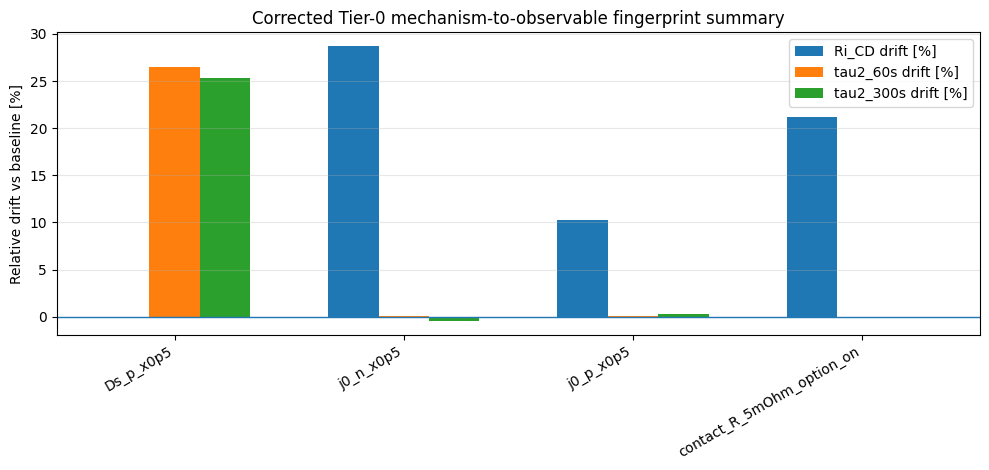

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/corrected_tier0_mechanism_fingerprint_summary.png


In [12]:
# Cell 11 — Fingerprint summary plot（绘制 Ri 与 tau2 的机制指纹总览）

plot_df = drift_table[drift_table["case"] != "baseline"].copy()

fig, ax = plt.subplots(figsize=(10, 4.8))

x = np.arange(len(plot_df))
width = 0.22

ax.bar(x - width, plot_df["Ri_CD_mohm_rel_pct"], width, label="Ri_CD drift [%]")
ax.bar(x, plot_df["biexp60_tau2_s_rel_pct"], width, label="tau2_60s drift [%]")
ax.bar(x + width, plot_df["biexp300_tau2_s_rel_pct"], width, label="tau2_300s drift [%]")

ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["case"], rotation=30, ha="right")
ax.set_ylabel("Relative drift vs baseline [%]")
ax.set_title("Corrected Tier-0 mechanism-to-observable fingerprint summary")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "corrected_tier0_mechanism_fingerprint_summary.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [13]:
# Cell 12 — Absolute fingerprint table（提取核心绝对值，便于解释和报告）

interpretation_cols = [
    "case",
    "Ri_CD_mohm",
    "Ri_EF_mohm",
    "biexp60_tau2_s",
    "biexp300_tau2_s",
    "contact_overpotential_absmax_mV",
]

absolute_fingerprint_table = corrected_table[interpretation_cols].copy()

display(absolute_fingerprint_table)

out_csv = DATA / "corrected_tier0_absolute_fingerprint_table.csv"
absolute_fingerprint_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)

,case,Ri_CD_mohm,Ri_EF_mohm,biexp60_tau2_s,biexp300_tau2_s,contact_overpotential_absmax_mV
0,baseline,23.545486,22.969868,48.698375,107.085635,0.0
1,Ds_p_x0p5,23.546335,22.947501,61.622140,134.162100,0.0
2,j0_n_x0p5,30.306247,29.684101,48.751164,106.585968,0.0
3,j0_p_x0p5,25.953266,25.499213,48.752695,107.440626,0.0
4,contact_R_5mOhm_option_on,28.545486,27.969868,48.698375,107.085635,25.0


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/corrected_tier0_absolute_fingerprint_table.csv


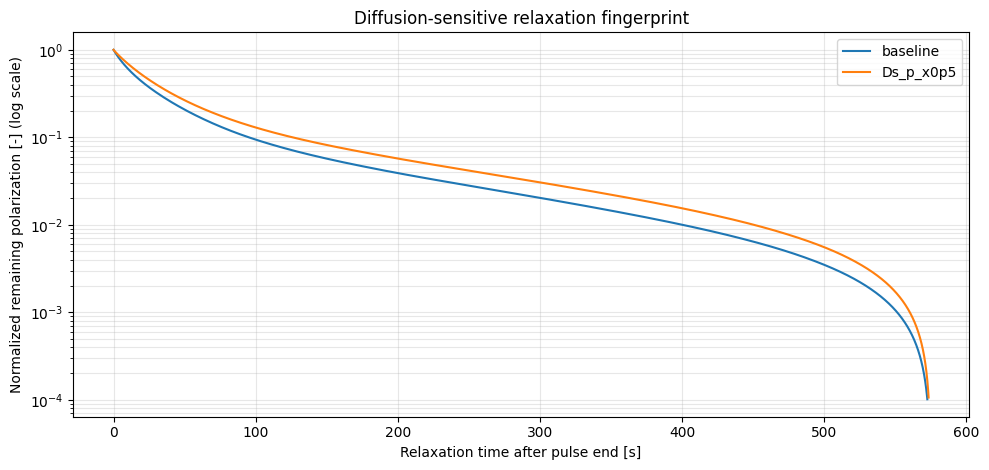

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/corrected_tier0_diffusion_relaxation_fingerprint.png


In [14]:
# Cell 13 — Relaxation waveform overlay
# 功能：对比 baseline 与 Ds_p_x0p5 的归一化 relaxation 曲线，审计扩散扰动是否改变慢恢复形状

case_a = "baseline"
case_b = "Ds_p_x0p5"

relax_a = corrected_relax[case_a]
relax_b = corrected_relax[case_b]

def normalized_remaining(relax):
    U0 = relax["voltage_V"].iloc[0]
    Uinf = np.median(relax.loc[relax["t_relax_s"] >= 550, "voltage_V"])
    y = (Uinf - relax["voltage_V"]) / (Uinf - U0)
    return np.asarray(y)

y_a = normalized_remaining(relax_a)
y_b = normalized_remaining(relax_b)

valid_a = y_a > 1e-4
valid_b = y_b > 1e-4

fig, ax = plt.subplots(figsize=(10, 4.8))

ax.semilogy(relax_a.loc[valid_a, "t_relax_s"], y_a[valid_a], label=case_a)
ax.semilogy(relax_b.loc[valid_b, "t_relax_s"], y_b[valid_b], label=case_b)

ax.set_xlabel("Relaxation time after pulse end [s]")
ax.set_ylabel("Normalized remaining polarization [-] (log scale)")
ax.set_title("Diffusion-sensitive relaxation fingerprint")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "corrected_tier0_diffusion_relaxation_fingerprint.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)